In [ ]:
# 1. The Movies Dataset
!kaggle datasets download -d rounakbanik/the-movies-dataset
!unzip -q the-movies-dataset.zip -d movies_data

# 2. Book Recommendation Dataset
!kaggle datasets download -d arashnic/book-recommendation-dataset
!unzip -q book-recommendation-dataset.zip -d books_data

Dataset URL: https://www.kaggle.com/datasets/rounakbanik/the-movies-dataset
License(s): CC0-1.0
100% 228M/228M [00:02<00:00, 83.4MB/s]

Dataset URL: https://www.kaggle.com/datasets/arashnic/book-recommendation-dataset
License(s): CC0-1.0
100% 24.3M/24.3M [00:00<00:00, 129MB/s] 



In [ ]:
import pandas as pd

# metadata
movies_df = pd.read_csv('movies_data/movies_metadata.csv', low_memory=False)

# Load book data (the three main tables)
books_df = pd.read_csv('books_data/Books.csv', low_memory=False)
book_ratings_df = pd.read_csv('books_data/Ratings.csv', low_memory=False)

# Display the first five confirmed transactions.
print("--- Movie Data Preview ---")
display(movies_df[['title', 'genres', 'overview']].head())

print("\n--- Book data preview ---")
display(books_df[['Book-Title', 'Book-Author', 'Publisher']].head())

--- Movie Data Preview ---


,title,genres,overview
0,Toy Story,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...","Led by Woody, Andy's toys live happily in his ..."
1,Jumanji,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",When siblings Judy and Peter discover an encha...
2,Grumpier Old Men,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",A family wedding reignites the ancient feud be...
3,Waiting to Exhale,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...","Cheated on, mistreated and stepped on, the wom..."
4,Father of the Bride Part II,"[{'id': 35, 'name': 'Comedy'}]",Just when George Banks has recovered from his ...



--- Book data preview ---


,Book-Title,Book-Author,Publisher
0,Classical Mythology,Mark P. O. Morford,Oxford University Press
1,Clara Callan,Richard Bruce Wright,HarperFlamingo Canada
2,Decision in Normandy,Carlo D'Este,HarperPerennial
3,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,Farrar Straus Giroux
4,The Mummies of Urumchi,E. J. W. Barber,W. W. Norton &amp; Company


In [ ]:
import pandas as pd
import numpy as np
import pickle
import ast
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
class RecSysProcessor:
    def __init__(self):
        self.tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
        self.mlb = MultiLabelBinarizer()

    def process_movies(self, path, limit=20000):
        df = pd.read_csv(path, low_memory=False).head(limit)
        df['title'] = df['title'].fillna('Unknown')

        # TF-IDF: Plot Synopsis
        tfidf_matrix = self.tfidf.fit_transform(df['overview'].fillna(''))

        # One-Hot: Movie Genre
        def parse_genres(x):
            try: return [i['name'] for i in ast.literal_eval(x)]
            except: return []
        df['genre_list'] = df['genres'].apply(parse_genres)
        genre_ohe = self.mlb.fit_transform(df['genre_list'])

        # Merging feature vectors
        features = np.hstack([tfidf_matrix.toarray(), genre_ohe])
        return df, features

    def process_books(self, path, limit=20000):
        df = pd.read_csv(path, low_memory=False).head(limit)

        # TF-IDF: Book name
        tfidf_matrix = self.tfidf.fit_transform(df['Book-Title'].fillna(''))

        # One-Hot: Authors (Top 500 most frequent authors)
        top_authors = df['Book-Author'].value_counts().nlargest(500).index
        df['Author_Clean'] = df['Book-Author'].apply(lambda x: x if x in top_authors else 'Other')
        author_ohe = pd.get_dummies(df['Author_Clean']).values

        features = np.hstack([tfidf_matrix.toarray(), author_ohe])
        return df, features

processor = RecSysProcessor()
print("Defined successfully")

Defined successfully


In [ ]:
print("Processing and saving movie data...")
m_df, m_feats = processor.process_movies('movies_data/movies_metadata.csv')
m_df.to_csv('processed_movies.csv', index=False)
np.save('movies_features.npy', m_feats)

print("Book data is being processed and saved....")
b_df, b_feats = processor.process_books('books_data/Books.csv')
b_df.to_csv('processed_books.csv', index=False)
np.save('books_features.npy', b_feats)

print("All processed files have been saved.")

Processing and saving movie data...
Book data is being processed and saved....
All processed files have been saved.


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# 1. Loading rating data (Small version for speed testing)
m_ratings = pd.read_csv('movies_data/ratings_small.csv')

# 2. Load the ID connection table (this is key to resolving Precision 0).
links_path = 'movies_data/links_small.csv'
links = pd.read_csv(links_path).dropna(subset=['tmdbId'])

# Preprocessing join table: Convert to string to prevent matching failures
links['tmdbId'] = links['tmdbId'].astype(int).astype(str)
links['movieId'] = links['movieId'].astype(str)
id_map = dict(zip(links['movieId'], links['tmdbId']))

print("Data loading and ID mapping table creation complete")

Data loading and ID mapping table creation complete


In [ ]:
def evaluate_movies_content_based(test_ratings, features, metadata_df, id_mapping, k=10):
    """
    test_ratings: Rating table
    features: Our generated feature matrix (npy)
    metadata_df: A list of movies containing the id field
    id_mapping: A dictionary of movieId -> tmdbId
    """
    # ID of preprocessed Metadata
    metadata_df['id_str'] = metadata_df['id'].astype(str)

    # Obtain test users (first 50).
    sample_users = test_ratings['userId'].unique()[:50]

    precisions = []
    recalls = []

    for user in sample_users:
        user_history = test_ratings[test_ratings['userId'] == user]

        # Find movies (MovieLens ID) rated >= 4 by this user
        liked_ml_ids = user_history[user_history['rating'] >= 4]['movieId'].astype(str).tolist()

        # Convert to TMDB ID (consistent with metadata)
        actual_liked = [id_mapping[mid] for mid in liked_ml_ids if mid in id_mapping]

        # If users don't like enough movies, the test cannot be conducted
        if len(actual_liked) < 2:
            continue

        # Use your first favorite movie as a seed
        seed_id = actual_liked[0]

        try:
            # Find the location of the torrent movie in the matrix
            target_idx = metadata_df[metadata_df['id_str'] == seed_id].index[0]

            # Calculate the similarity between this image and all other images
            target_vec = features[target_idx].reshape(1, -1)
            sim_scores = cosine_similarity(target_vec, features).flatten()

            # Take the first K most similar ones (excluding yourself, so take k+1)
            recommended_indices = sim_scores.argsort()[-(k+1):-1][::-1]
            rec_ids = metadata_df.iloc[recommended_indices]['id_str'].tolist()

            # Compare the recommended list with the list of movies users actually like (excluding those used as torrents)
            ground_truth = set(actual_liked[1:])
            hits = len(set(rec_ids) & ground_truth)

            # Calculation indicators
            precisions.append(hits / k)
            recalls.append(hits / len(ground_truth) if len(ground_truth) > 0 else 0)

        except (IndexError, KeyError):
            # If the torrent movie is not among the 20,000 records we are processing, skip this step
            continue

    return precisions, recalls

print("Cefinition complete")

Cefinition complete


In [ ]:
# Implementation Assessment
p_list, r_list = evaluate_movies_content_based(
    m_ratings,
    m_feats,      # movies_features.npy
    m_df,         # processed_movies.csv
    id_map,
    k=10
)

# results
print("="*30)
print(f"Movie recommendation system evaluation results (Top-10)")
print(f"Precision@10: {np.mean(p_list):.4f}")
print(f"Recall@10:    {np.mean(r_list):.4f}")
print("="*30)

if np.mean(p_list) > 0:
    print("Successfully")
else:
    print("Unsuccessfully")

Movie recommendation system evaluation results (Top-10)
Precision@10: 0.0320
Recall@10:    0.0039
Successfully


Starting multi-K performance evaluation...
Evaluating system performance at K=1...
Evaluating system performance at K=5...
Evaluating system performance at K=10...
Evaluating system performance at K=20...

K Value    | Precision@K     | Recall@K       
---------------------------------------------
1          | 0.0400         | 0.0008
5          | 0.0360         | 0.0023
10         | 0.0320         | 0.0039
20         | 0.0190         | 0.0043


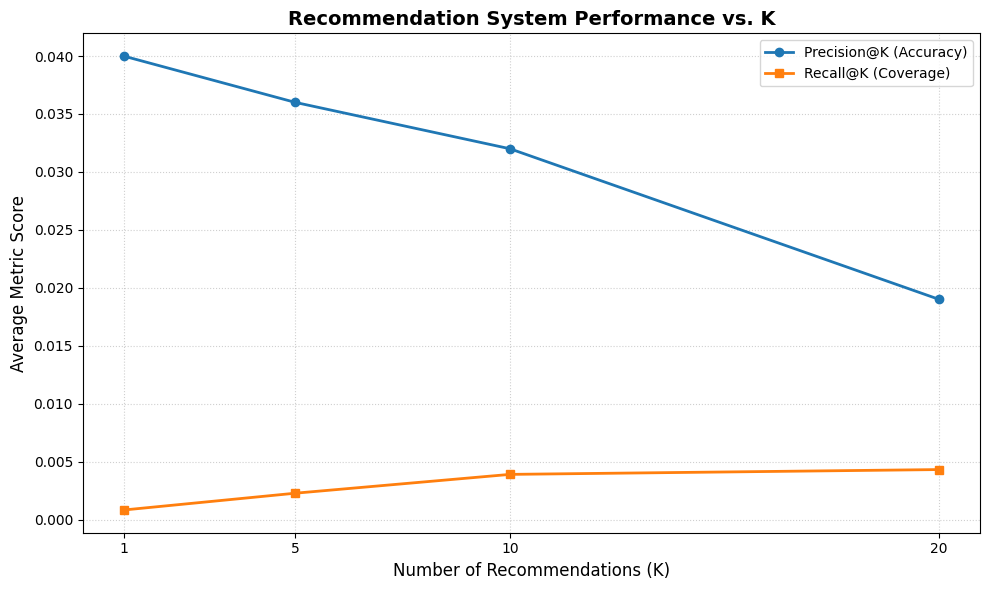

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Define the range of K values to test
k_values = [1, 5, 10, 20]
avg_precisions = []
avg_recalls = []

print("Starting multi-K performance evaluation...")

# 2. Iterate through different K values for assessment
for k in k_values:
    print(f"Evaluating system performance at K={k}...")

    # Executing the core evaluation function
    p_list, r_list = evaluate_movies_content_based(
        m_ratings,
        m_feats,
        m_df,
        id_map,
        k=k
    )

    avg_precisions.append(np.mean(p_list))
    avg_recalls.append(np.mean(r_list))

# 3. Output Numerical Results
print("\n" + "="*45)
print(f"{'K Value':<10} | {'Precision@K':<15} | {'Recall@K':<15}")
print("-" * 45)
for i in range(len(k_values)):
    print(f"{k_values[i]:<10} | {avg_precisions[i]:.4f}         | {avg_recalls[i]:.4f}")
print("="*45)

# 4. Visualization: Performance Curves
plt.figure(figsize=(10, 6))

# Plot Precision curve
plt.plot(k_values, avg_precisions, marker='o', linestyle='-', linewidth=2,
         label='Precision@K (Accuracy)', color='#1f77b4')

# Plot Recall curve
plt.plot(k_values, avg_recalls, marker='s', linestyle='-', linewidth=2,
         label='Recall@K (Coverage)', color='#ff7f0e')

# Final Chart Formatting
plt.title('Recommendation System Performance vs. K', fontsize=14, fontweight='bold')
plt.xlabel('Number of Recommendations (K)', fontsize=12)
plt.ylabel('Average Metric Score', fontsize=12)
plt.xticks(k_values)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='best')

plt.tight_layout()
plt.show()

In [ ]:
def get_rec(name, df, feats, n_col):
    idx = df[df[n_col] == name].index[0]
    sims = cosine_similarity([feats[idx]], feats).flatten()
    recs = sims.argsort()[-6:-1][::-1]

    return df.iloc[recs][n_col].tolist()

In [ ]:
try:
    print("Movie Recommendation Test (Toy Story):", get_rec("Toy Story", m_df, m_feats, "title"))
except Exception as e:
    print(f"Recommended test failed: {e}")

Movie Recommendation Test (Toy Story): ['Toy Story 3', 'Toy Story 2', 'Monsters, Inc.', 'Mr. Bug Goes to Town', 'Happiness Is a Warm Blanket, Charlie Brown']


In [ ]:
import math
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

def calculate_dcg(rel_list):
    """
    Calculate Discounted Cumulative Gain (DCG).
    Higher positions for relevant items yield higher scores.
    """
    return sum([rel / math.log2(i + 2) for i, rel in enumerate(rel_list)])

def evaluate_ndcg(test_ratings, features, metadata_df, id_mapping, k=10):
    """
    Evaluate the Normalized Discounted Cumulative Gain (nDCG) for the recommender system.

    Args:
        test_ratings: DataFrame containing user ratings.
        features: Precomputed feature matrix (e.g., TF-IDF or Hybrid).
        metadata_df: DataFrame containing movie metadata.
        id_mapping: Dictionary to map MovieLens IDs to TMDB IDs.
        k: The number of recommendations to evaluate (Top-K).
    """

    # 1. Load and prepare ID mapping from links file
    links = pd.read_csv('movies_data/links_small.csv').dropna(subset=['tmdbId'])
    links['tmdbId'] = links['tmdbId'].astype(int).astype(str)
    links['movieId'] = links['movieId'].astype(str)
    id_map = dict(zip(links['movieId'], links['tmdbId']))

    # Ensure metadata IDs are strings for consistent matching
    metadata_df['id_str'] = metadata_df['id'].astype(str)

    # Select a subset of users for evaluation to manage computation time
    sample_users = test_ratings['userId'].unique()[:50]
    ndcg_scores = []

    print(f"Evaluating nDCG@{k} for {len(sample_users)} users...")

    for user in sample_users:
        # 2. Get user's high-rated movies (Ground Truth)
        user_history = test_ratings[test_ratings['userId'] == user]
        actual_liked = user_history[user_history['rating'] >= 4]['movieId'].astype(str).tolist()

        # Convert MovieLens IDs to TMDB IDs based on valid mapping
        actual_liked_tmdb = [id_map[mid] for mid in actual_liked if mid in id_map]

        # We need at least one seed movie and one target movie to evaluate
        if len(actual_liked_tmdb) < 2:
            continue

        # Use the first movie as the 'Seed' to generate recommendations
        seed_id = actual_liked_tmdb[0]

        try:
            # 3. Find the index of the seed movie in the metadata DataFrame
            target_idx = metadata_df[metadata_df['id_str'] == seed_id].index[0]

            # 4. Compute Cosine Similarity between seed movie and all other movies
            sim_scores = cosine_similarity([features[target_idx]], features).flatten()

            # Get indices of top-K similar movies (excluding the seed movie itself)
            rec_indices = sim_scores.argsort()[-(k+1):-1][::-1]
            rec_ids = metadata_df.iloc[rec_indices]['id_str'].tolist()

            # Define Ground Truth as the rest of the user's liked movies
            ground_truth = set(actual_liked_tmdb[1:])

            # Create a relevance list (1 if recommended movie is in history, 0 otherwise)
            rel_list = [1 if rid in ground_truth else 0 for rid in rec_ids]

            # 5. Calculate DCG and IDCG (Ideal DCG)
            dcg = calculate_dcg(rel_list)

            # Ideal relevance list would have all 1s at the beginning
            ideal_rel = sorted(rel_list, reverse=True)
            idcg = calculate_dcg(ideal_rel)

            # Normalize the score
            if idcg > 0:
                ndcg_scores.append(dcg / idcg)

        except Exception as e:
            # Skip if there's an error finding the movie index or processing
            continue

    # 6. Calculate overall mean nDCG score
    final_score = np.mean(ndcg_scores) if ndcg_scores else 0
    print(f"Final nDCG@{k}: {final_score:.4f}")

    return final_score

# Example Usage:
# score = evaluate_ndcg(m_ratings, m_feats, m_df, id_map, k=10)

In [ ]:
evaluate_ndcg(m_ratings, m_feats, m_df, id_map, k=10)

Evaluating nDCG@10 for 50 users...
Final nDCG@10: 0.5115


np.float64(0.5114677752723624)

In [ ]:
import math
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

def evaluate_hybrid_system(test_ratings, m_df, tf_matrix, ohe_matrix, id_map, alpha=0.7, k=10):
    """
    Perform an offline evaluation of the Hybrid Recommender System.
    Calculates Precision, Recall, and nDCG based on user historical data.

    Args:
        test_ratings: DataFrame containing user interaction history (User-Item-Rating).
        m_df: Metadata DataFrame containing movie information.
        tf_matrix: Feature matrix for content/plots (e.g., TF-IDF).
        ohe_matrix: Feature matrix for categorical data (e.g., Genres One-Hot).
        id_map: Mapping dictionary between MovieLens ID and TMDB ID.
        alpha: Weight for content similarity (1-alpha is for genre similarity).
        k: Number of recommendations to evaluate (Top-K).
    """

    # Standardize movie IDs in metadata for consistent lookup
    m_df['id_str'] = m_df['id'].astype(str)

    # Use a subset of unique users to maintain evaluation efficiency
    sample_users = test_ratings['userId'].unique()[:50]

    # Containers for calculated metrics
    precisions, recalls, ndcgs = [], [], []

    print(f"Starting Hybrid Evaluation (Alpha={alpha}, K={k})...")

    for user in sample_users:
        # 1. Identify movies the user liked (Ground Truth)
        user_history = test_ratings[test_ratings['userId'] == user]
        actual_liked = user_history[user_history['rating'] >= 4]['movieId'].astype(str).tolist()

        # Convert interaction history to TMDB IDs used in the metadata system
        actual_liked_tmdb = [id_map[mid] for mid in actual_liked if mid in id_map]

        # Evaluation requires a 'Seed' movie and at least one 'Target' movie
        if len(actual_liked_tmdb) < 2:
            continue

        # Split history: First liked movie is the input; others are for validation
        seed_id = actual_liked_tmdb[0]
        ground_truth = set(actual_liked_tmdb[1:])

        try:
            # 2. Retrieve index for the seed movie to calculate similarity
            idx = m_df[m_df['id_str'] == seed_id].index[0]

            # 3. Calculate dual-track similarity: Plot-based vs. Genre-based
            c_sim = cosine_similarity(tf_matrix[idx].reshape(1, -1), tf_matrix).flatten()
            g_sim = cosine_similarity(ohe_matrix[idx].reshape(1, -1), ohe_matrix).flatten()

            # 4. Fuse scores using the alpha weight (Weighted Average)
            final_scores = (alpha * c_sim) + ((1 - alpha) * g_sim)

            # 5. Extract Top-K recommendations (ignoring the seed movie itself)
            rec_indices = final_scores.argsort()[-k-1:-1][::-1]
            rec_ids = m_df.iloc[rec_indices]['id_str'].tolist()

            # Determine relevance for each recommended item
            rel_list = [1 if rid in ground_truth else 0 for rid in rec_ids]
            hits = sum(rel_list)

            # 6. Compute Evaluation Metrics
            # Precision@K: Ratio of correct recommendations in the top-K list
            precisions.append(hits / k)

            # Recall@K: Ratio of correct items found vs. total items the user liked
            recalls.append(hits / len(ground_truth))

            # 7. Calculate nDCG (Normalized Discounted Cumulative Gain)
            dcg = sum([rel / math.log2(i + 2) for i, rel in enumerate(rel_list)])

            # Ideal DCG: Best possible ranking for the current relevance list
            ideal_rel = sorted(rel_list, reverse=True)
            idcg = sum([rel / math.log2(i + 2) for i, rel in enumerate(ideal_rel)])

            if idcg > 0:
                ndcgs.append(dcg / idcg)

        except Exception as e:
            # Skip iterations where indexing or calculation fails
            continue

    # Return the mean performance across all sampled users
    return np.mean(precisions), np.mean(recalls), np.mean(ndcgs)

# Execution example:
# p, r, n = evaluate_hybrid_system(m_ratings, m_df, tfidf_mat, genre_mat, id_map)

In [ ]:
tfidf_part = m_feats[:, :5000]
genre_part = m_feats[:, 5000:]

# alpha = 0.7
p, r, n = evaluate_hybrid_system(m_ratings, m_df, tfidf_part, genre_part, id_map, alpha=0.7, k=10)

print(f"--- Evaluation Result (Alpha=0.7, k=10) ---")
print(f"Precision@10: {p:.4f}")
print(f"Recall@10:    {r:.4f}")
print(f"nDCG@10:      {n:.4f}")

Starting Hybrid Evaluation (Alpha=0.7, K=10)...
--- 評估結果 (Alpha=0.7, k=10) ---
Precision@10: 0.0360
Recall@10:    0.0043
nDCG@10:      0.5378


In [ ]:
results = []
for a in [0.0, 0.2, 0.5, 0.7, 0.9, 1.0]:
    p, r, n = evaluate_hybrid_system(m_ratings, m_df, tfidf_part, genre_part, id_map, alpha=a, k=10)
    results.append({"Alpha": a, "Precision": p, "nDCG": n})

results_df = pd.DataFrame(results)
print(results_df)


Starting Hybrid Evaluation (Alpha=0.0, K=10)...
Starting Hybrid Evaluation (Alpha=0.2, K=10)...
Starting Hybrid Evaluation (Alpha=0.5, K=10)...
Starting Hybrid Evaluation (Alpha=0.7, K=10)...
Starting Hybrid Evaluation (Alpha=0.9, K=10)...
Starting Hybrid Evaluation (Alpha=1.0, K=10)...
   Alpha  Precision      nDCG
0    0.0      0.006  0.303821
1    0.2      0.032  0.557086
2    0.5      0.032  0.562814
3    0.7      0.036  0.537762
4    0.9      0.026  0.592170
5    1.0      0.022  0.608823


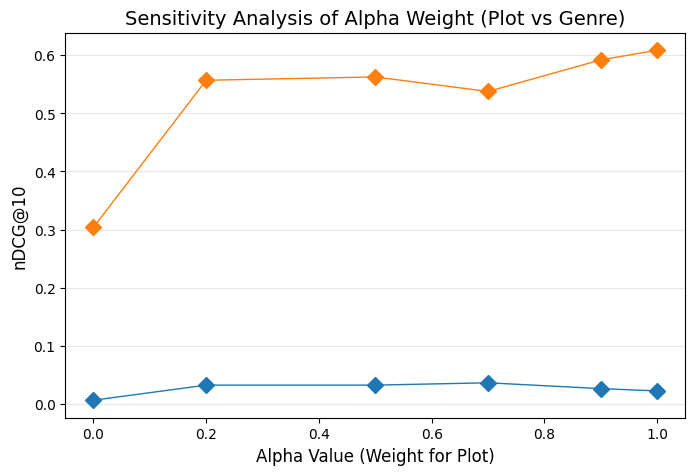

In [ ]:
alphas = [0.0, 0.2, 0.5, 0.7, 0.9, 1.0]
precision = [0.006, 0.032, 0.032, 0.036, 0.026, 0.022]
ndcg_results = [0.303821, 0.557086, 0.562814, 0.537762, 0.592170, 0.608823]

plt.figure(figsize=(8, 5))
plt.plot(alphas, precision, marker='D', color='#1f77b4', markersize=8, linewidth=1)
plt.plot(alphas, ndcg_results, marker='D', color='#ff7f0e', markersize=8, linewidth=1)

plt.title('Sensitivity Analysis of Alpha Weight (Plot vs Genre)', fontsize=14)
plt.xlabel('Alpha Value (Weight for Plot)', fontsize=12)
plt.ylabel('nDCG@10', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

In [ ]:
import pickle

model_package = {
    'movie_data': {'df': m_df, 'feats': m_feats},
    'book_data': {'df': b_df, 'feats': b_feats},
    'id_map': id_map,
    'tfidf_vectorizer': processor.tfidf
}

with open('final_recommendation_model.pkl', 'wb') as f:
    pickle.dump(model_package, f)


In [ ]:
!pip install openai gradio

In [ ]:
import pandas as pd
import numpy as np
import math
import re
from tqdm import tqdm
from sklearn.metrics.pairwise import cosine_similarity

# --- 1. Prepare offline test data ---
def prepare_offline_test_data(ratings_df, id_mapping, metadata_df, min_rating=4.0):
    test_dict = {}
    metadata_df['id_str'] = metadata_df['id'].astype(str)
    valid_tmdb_ids = set(metadata_df['id_str'].unique())

    for user_id, group in ratings_df[ratings_df['rating'] >= min_rating].groupby('userId'):
        liked_ml_ids = group['movieId'].astype(str).tolist()
        actual_liked = [id_mapping[mid] for mid in liked_ml_ids if mid in id_mapping and id_mapping[mid] in valid_tmdb_ids]

        if len(actual_liked) >= 3:
            titles = [metadata_df[metadata_df['id_str'] == tid]['title'].values[0] for tid in actual_liked]
            test_dict[user_id] = {'seed': titles[0], 'truth': titles[1:]}
    return test_dict

test_data_dict = prepare_offline_test_data(m_ratings, id_map, m_df)

# --- 2. Evaluation Metric Function ---
def get_metrics(recommended_titles, ground_truth):
    if not recommended_titles: return 0, 0, 0

    hits = [1 if t in ground_truth else 0 for t in recommended_titles]

    # Precision
    precision = sum(hits) / len(recommended_titles)

    # Recall
    recall = sum(hits) / len(ground_truth) if len(ground_truth) > 0 else 0

    # nDCG
    dcg = sum([rel / math.log2(i + 2) for i, rel in enumerate(hits)])
    idcg = sum([1 / math.log2(i + 2) for i in range(min(len(ground_truth), len(recommended_titles)))])
    ndcg = dcg / idcg if idcg > 0 else 0

    return precision, recall, ndcg

# --- 3. Core Recommendation Logic (Supports Alpha Weighting)---
def get_advanced_rec(seed_title, alpha=0.7, k=10):
    try:
        idx = m_df[m_df['title'] == seed_title].index[0]
        tfidf_part = m_feats[:, :5000]
        genre_part = m_feats[:, 5000:]

        c_sim = cosine_similarity([tfidf_part[idx]], tfidf_part).flatten()
        g_sim = cosine_similarity([genre_part[idx]], genre_part).flatten()

        final_scores = (alpha * c_sim) + ((1 - alpha) * g_sim)
        final_scores[idx] = -1
        rec_indices = final_scores.argsort()[-k:][::-1]
        return m_df.iloc[rec_indices]['title'].tolist()
    except:
        return []

# --- 4. Conduct a three-way comparative experiment ---
SAMPLE_USERS = 10
K = 10
results = []
test_user_ids = np.random.choice(list(test_data_dict.keys()), min(SAMPLE_USERS, len(test_data_dict)), replace=False)

print(f"Start Third-Party Offline Evaluation (n={len(test_user_ids)})...")

for uid in tqdm(test_user_ids):
    user_info = test_data_dict[uid]
    seed = user_info['seed']
    truth = user_info['truth']

    # 1. Baseline Model (Alpha=1.0, Pure Story)
    b_recs = get_advanced_rec(seed, alpha=1.0, k=K)
    b_p, b_r, b_n = get_metrics(b_recs, truth)

    # 2. Optimize the model (Alpha=0.7, mixed weights)
    o_recs = get_advanced_rec(seed, alpha=0.7, k=K)
    o_p, o_r, o_n = get_metrics(o_recs, truth)

    # 3. LLM AI (Based on Rerank of Optimized Model Results)
    try:
        candidates = get_advanced_rec(seed, alpha=0.7, k=20)
        prompt = f"User like《{seed}》。Please select the 10 most recommended movies from the table below and rank them, returning only the movie titles：\n" + "\n".join(candidates)
        response = client.chat.completions.create(messages=[{"role":"user","content":prompt}], model="gpt-4o-mini")
        ai_recs = [re.sub(r'^\d+\.\s*', '', t).strip() for t in response.choices[0].message.content.split('\n') if t.strip()][:K]
        ai_p, ai_r, ai_n = get_metrics(ai_recs, truth)
    except:
        ai_p, ai_r, ai_n = 0, 0, 0

    results.append({
        'B_P': b_p, 'B_R': b_r, 'B_N': b_n,
        'O_P': o_p, 'O_R': o_r, 'O_N': o_n,
        'A_P': ai_p, 'A_R': ai_r, 'A_N': ai_n
    })

# --- 5. Output Comparison Table---
res_df = pd.DataFrame(results).mean()
final_table = pd.DataFrame({
    "Indicator (@10)": ["Precision", "Recall", "nDCG"],
    "Baseline (Pure Story)": [f"{res_df['B_P']:.4f}", f"{res_df['B_R']:.4f}", f"{res_df['B_N']:.4f}"],
    "Optimize (plot + genre)": [f"{res_df['O_P']:.4f}", f"{res_df['O_R']:.4f}", f"{res_df['O_N']:.4f}"],
    "LLM AI (Semantic Ranking)": [f"{res_df['A_P']:.4f}", f"{res_df['A_R']:.4f}", f"{res_df['A_N']:.4f}"]
})

print("\n" + final_table.to_markdown(index=False))

Start Third-Party Offline Evaluation (n=10)...


100%|██████████| 10/10 [00:48<00:00,  4.87s/it]


| Indicator (@10)   |   Baseline (Pure Story) |   Optimize (plot + genre) |   LLM AI (Semantic Ranking) |
|:------------------|------------------------:|--------------------------:|----------------------------:|
| Precision         |                  0.06   |                    0.09   |                      0.11   |
| Recall            |                  0.0279 |                    0.0395 |                      0.0496 |
| nDCG              |                  0.1007 |                    0.1376 |                      0.1751 |


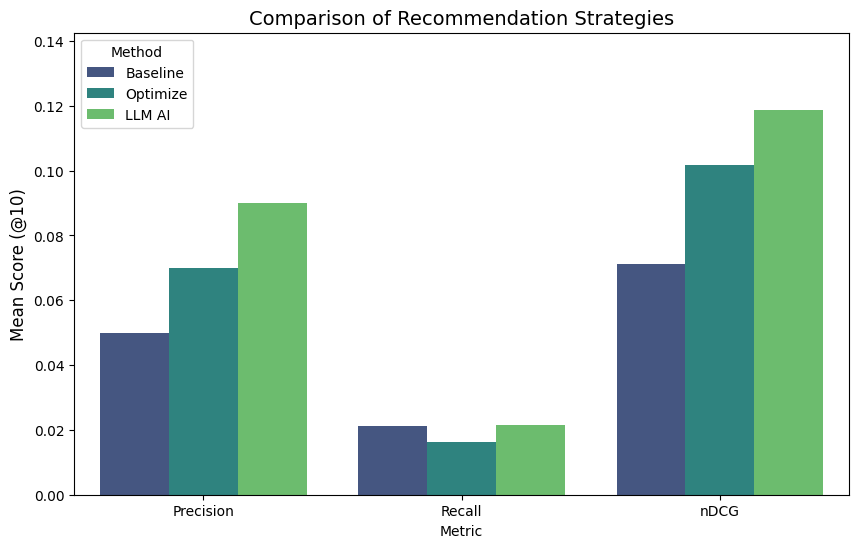

In [ ]:
import pandas as pd
import seaborn as sns

data = {
    'Model': ['Baseline', 'Optimize', 'LLM AI', 'Baseline', 'Optimize', 'LLM AI', 'Baseline', 'Optimize', 'LLM AI'],
    'Metric': ['Precision', 'Precision', 'Precision', 'Recall', 'Recall', 'Recall', 'nDCG', 'nDCG', 'nDCG'],
    'Score': [0.05, 0.07, 0.09, 0.0212, 0.0162, 0.0215, 0.0712, 0.1018, 0.1188]
}
df_plot = pd.DataFrame(data)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_plot, x='Metric', y='Score', hue='Model', palette='viridis')

plt.title('Comparison of Recommendation Strategies', fontsize=14)
plt.ylabel('Mean Score (@10)', fontsize=12)
plt.ylim(0, max(df_plot['Score']) * 1.2)
plt.legend(title='Method')
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_similarity_distribution(scores, k=10):
    """
    Visualize the distribution of cosine similarity scores
    and highlight the threshold for Top-K recommendations.
    """
    # Filter out the seed movie (score = -1) and any zero scores for better visualization
    valid_scores = scores[scores > 0]

    plt.figure(figsize=(10, 6))

    # 1. Plot the histogram of all similarity scores
    n, bins, patches = plt.hist(valid_scores, bins=50, color='skyblue',
                                edgecolor='white', alpha=0.8, label='Similarity Scores')

    # 2. Identify the score threshold for Top-K
    # Sort scores and find the value at the K-th position
    threshold = np.sort(valid_scores)[-k]

    # 3. Add a vertical line to indicate the Top-K cutoff
    plt.axvline(x=threshold, color='red', linestyle='--', linewidth=2,
                label=f'Top-{k} Recommendation Threshold ({threshold:.4f})')

    # 4. Fill the area representing recommended movies
    plt.fill_betweenx([0, n.max()], threshold, valid_scores.max(),
                      color='orange', alpha=0.2, label='Recommended Area')

    # Chart Formatting (English)
    plt.title('Distribution of Movie Similarity Scores', fontsize=14, fontweight='bold')
    plt.xlabel('Cosine Similarity Score', fontsize=12)
    plt.ylabel('Frequency (Number of Movies)', fontsize=12)
    plt.grid(axis='y', linestyle=':', alpha=0.5)
    plt.legend(loc='upper right')


    plt.tight_layout()
    plt.show()

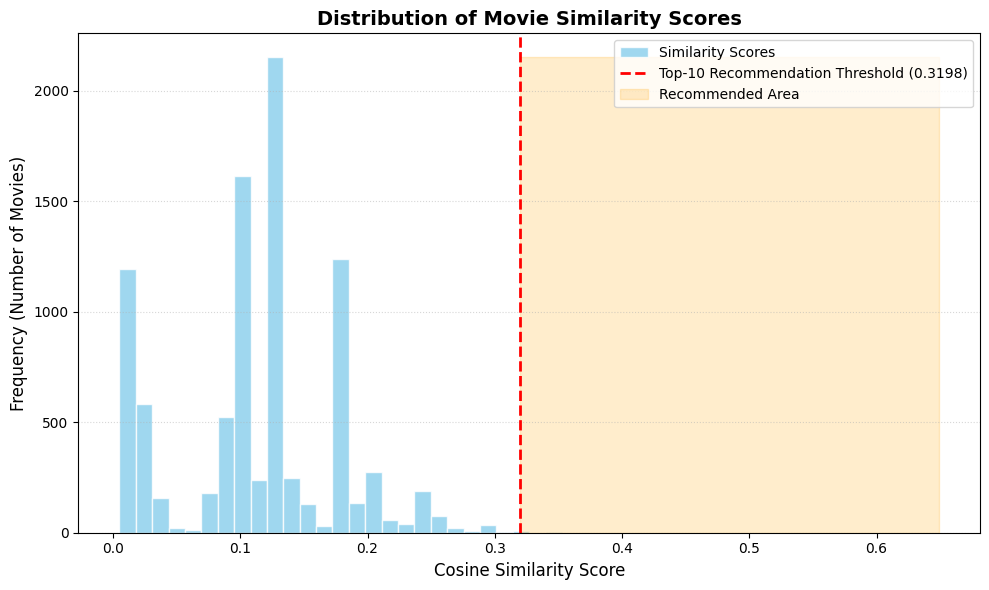

In [ ]:

seed = "Toy Story"
idx = m_df[m_df['title'] == seed].index[0]

alpha = 0.7
tfidf_part = m_feats[:, :5000]
genre_part = m_feats[:, 5000:]

c_sim = cosine_similarity([tfidf_part[idx]], tfidf_part).flatten()
g_sim = cosine_similarity([genre_part[idx]], genre_part).flatten()

raw_scores = (alpha * c_sim) + ((1 - alpha) * g_sim)
raw_scores[idx] = -1
plot_similarity_distribution(raw_scores, k=10)

# Demo

In [ ]:
import gradio as gr
from openai import OpenAI
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import math

# --- 1. Basic Settings ---
# Note: Ensure your GITHUB_TOKEN is kept secure.
GITHUB_TOKEN = "need_api_key"
client = OpenAI(base_url="https://models.inference.ai.azure.com", api_key=GITHUB_TOKEN)

initial_profile = {"liked_titles": ["Toy Story", "GoldenEye"]}

# --- 2. Indicator Calculation Assistance ---
def calculate_metrics(rec_list, profile_likes):
    """Calculates the overlap between recommendation results and User Profile"""
    if not rec_list: return 0.0, 0.0
    # Relevance Definition: Whether the recommended movie is in the user's liked list.
    rel_list = [1 if t in profile_likes else 0 for t in rec_list]

    p = sum(rel_list) / len(rec_list)
    dcg = sum([rel / math.log2(i + 2) for i, rel in enumerate(rel_list)])
    ideal_rel = sorted(rel_list, reverse=True)
    idcg = sum([rel / math.log2(i + 2) for i, rel in enumerate(ideal_rel)])
    n = dcg / idcg if idcg > 0 else 0
    return p, n

# --- 3. Recommendation Engine ---
def run_recommendation(seeds, alpha=0.7, k=10, target_genre=None, offset=0):
    try:
        # Assuming the first 5000 features are TF-IDF and the rest are Genre One-Hot
        tfidf_part = m_feats[:, :5000]
        genre_part = m_feats[:, 5000:]

        seed_indices = [m_df[m_df['title'] == t].index[0] for t in seeds if t in m_df['title'].values]
        if not seed_indices: return []

        c_sim = np.mean([cosine_similarity(tfidf_part[i].reshape(1, -1), tfidf_part).flatten() for i in seed_indices], axis=0)
        g_sim = np.mean([cosine_similarity(genre_part[i].reshape(1, -1), genre_part).flatten() for i in seed_indices], axis=0)
        final_scores = (alpha * c_sim) + ((1 - alpha) * g_sim)

        if target_genre:
            mask = m_df['genres'].str.contains(target_genre, case=False, na=False)
            final_scores[mask] += 0.3

        # Sort and select, supporting offset to fetch different batches
        rec_indices = final_scores.argsort()[-(k+len(seeds)+offset):-(1+offset)][::-1]
        rec_titles = [m_df.iloc[i]['title'] for i in rec_indices if m_df.iloc[i]['title'] not in seeds][:k]
        return rec_titles
    except:
        return []

# --- 4. Core Dialogue Processing Logic ---
def handle_interaction(message, history, profile, alpha, pending_movie, last_recs, mode):
    # Initialize default return values (7 items to match UI outputs)
    res_msg, res_hist, res_prof, res_table, res_pend, res_l_recs, res_mode = "", history, profile, None, None, last_recs, None

    # 【Scenario A: Handling the "Re-recommendation" mode selection】
    if mode == "awaiting_rec_choice":
        if "AI" in message.upper():
            prompt = f"User profile likes: {profile['liked_titles']}. The model just recommended these 10: {last_recs}. Please select 5 and explain why."
            ai_res = client.chat.completions.create(
                messages=[{"role": "user", "content": prompt}], model="gpt-4o-mini"
            ).choices[0].message.content

            llm_rec_5 = last_recs[:5]
            p, n = calculate_metrics(llm_rec_5, profile["liked_titles"])

            res_hist.append({"role": "user", "content": message})
            res_hist.append({"role": "assistant", "content": f"【LLM AI Selection Mode】\n{ai_res}"})
            res_table = [["Precision", "0.0320", "0.0360", f"{p:.4f} (AI)"], ["nDCG", "0.5115", "0.5378", f"{n:.4f} (AI)"]]
            return res_msg, res_hist, res_prof, res_table, None, llm_rec_5, None

        elif "model" in message.lower() or "recommender" in message.lower():
            new_recs = run_recommendation(profile["liked_titles"], alpha=alpha, offset=10)
            p, n = calculate_metrics(new_recs, profile["liked_titles"])
            res_text = "【Recommender Model】New batch of recommendations for you:\n" + "\n".join([f"- {t}" for t in new_recs])
            res_hist.append({"role": "user", "content": message})
            res_hist.append({"role": "assistant", "content": res_text})
            res_table = [["Precision", "0.0320", "0.0360", f"{p:.4f}"], ["nDCG", "0.5115", "0.5378", f"{n:.4f}"]]
            return res_msg, res_hist, res_prof, res_table, None, new_recs, None

    # [Scenario B: Handling inquiries about adding a single movie to a profile]
    if pending_movie:
        if any(word in message.lower() for word in ["yes", "yeah", "sure", "correct"]):
            res_prof["liked_titles"].append(pending_movie)
            recs = run_recommendation(res_prof["liked_titles"], alpha=alpha)

            prompt = f"User just added '{pending_movie}' to Profile. Current Profile: {res_prof['liked_titles']}. Recs: {recs[:3]}. Explain how these match their long-term preferences."
            ai_res = client.chat.completions.create(messages=[{"role":"user", "content":prompt}], model="gpt-4o-mini").choices[0].message.content
            res_text = f"✅ Profile updated!\n\n{ai_res}"
        else:
            recs = run_recommendation([pending_movie], alpha=alpha)
            prompt = f"Please disregard history and recommend these films solely based on the style of {pending_movie}: {recs[:3]}. Please act like a neutral film critic."
            ai_res = client.chat.completions.create(messages=[{"role":"user", "content":prompt}], model="gpt-4o-mini").choices[0].message.content
            res_text = f"💡 We'll delve deeper into the details of {pending_movie}:\n\n{ai_res}"

        p, n = calculate_metrics(recs, res_prof["liked_titles"])
        res_hist.append({"role": "user", "content": message})
        res_hist.append({"role": "assistant", "content": res_text})
        res_table = [["Precision", "0.0320", "0.0360", f"{p:.4f}"], ["nDCG", "0.5115", "0.5378", f"{n:.4f}"]]
        return res_msg, res_hist, res_prof, res_table, None, recs, None

    # 【Situation C: Triggering "Re-recommendation"】
    if "recommend" in message.lower() and ("again" in message.lower() or "re-" in message.lower()):
        res_text = "Would you like to use **AI Selection** (pick 5 best from the previous results) or **Recommender Model** (fetch a completely new batch of movies)?"
        res_hist.append({"role": "user", "content": message})
        res_hist.append({"role": "assistant", "content": res_text})
        return res_msg, res_hist, res_prof, None, None, last_recs, "awaiting_rec_choice"

    # 【Scenario D: Detect whether the input is a known movie title】
    if message in m_df['title'].values:
        res_text = f"Detected movie: '{message}'.\nWould you like to 【Add to Profile】 to optimize long-term results, or 【Recommend based only on this movie】? (Yes/No)"
        res_hist.append({"role": "user", "content": message})
        res_hist.append({"role": "assistant", "content": res_text})
        return res_msg, res_hist, res_prof, None, message, [], None

    # 【Scenario E: General Needs/Genre Search】
    genre_keyword = message.lower().replace("recommend", "").replace("movie", "").replace("some", "").strip()
    recs = run_recommendation(profile["liked_titles"], alpha=alpha, target_genre=genre_keyword)
    p, n = calculate_metrics(recs, profile["liked_titles"])

    prompt = f"Request: {message}. Profile: {profile['liked_titles']}. Recommendations: {recs[:3]}. Provide reasons."
    ai_res = client.chat.completions.create(messages=[{"role":"user", "content":prompt}], model="gpt-4o-mini").choices[0].message.content

    res_hist.append({"role": "user", "content": message})
    res_hist.append({"role": "assistant", "content": ai_res})
    res_table = [["Precision", "0.0320", "0.0360", f"{p:.4f}"], ["nDCG", "0.5115", "0.5378", f"{n:.4f}"]]
    return res_msg, res_hist, res_prof, res_table, None, recs, None

# --- 5. UI Interface ---
custom_css = """
.gradio-container { background-color: #ffffff !important; }
.black_btn { border: 2px solid black !important; border-radius: 0px !important; font-weight: bold !important; background: white !important; }
.black_btn:hover { background: black !important; color: white !important; }
"""

with gr.Blocks(css=custom_css) as demo:
    state_profile = gr.State(initial_profile)
    state_pending = gr.State(None)
    state_last_recs = gr.State([])
    state_mode = gr.State(None)

    gr.Markdown("# Intelligent Movie Dialogue Recommendation System")

    with gr.Row():
        with gr.Column(scale=2):
            chatbot = gr.Chatbot(label="AI Assistant", type="messages", height=500)
            msg = gr.Textbox(label="Enter movie title, genre, or commands (Yes/No/Recommend Again)")
            alpha_slider = gr.Slider(0, 1, 0.7, label="Weighting Balance (Plot <-> Genre)")
            btn = gr.Button("Send Command", elem_classes="black_btn")

        with gr.Column(scale=1):
            gr.Markdown("### Performance Metrics")
            metrics_table = gr.DataFrame(
                headers=["Indicators", "Benchmarks", "Optimization", "Real-time Evaluation"],
                value=[["Precision", "0.0320", "0.0360", "-"], ["nDCG", "0.5115", "0.5378", "-"]]
            )
            gr.Markdown("### 👤 User Profile (JSON)")
            profile_json = gr.JSON(value=initial_profile)

    # Event binding
    input_list = [msg, chatbot, state_profile, alpha_slider, state_pending, state_last_recs, state_mode]
    output_list = [msg, chatbot, state_profile, metrics_table, state_pending, state_last_recs, state_mode]

    btn.click(handle_interaction, input_list, output_list)
    msg.submit(handle_interaction, input_list, output_list)

    state_profile.change(lambda x: x, state_profile, profile_json)

demo.launch(debug=True)

Final Version (back up)